In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv(r'/Users/aryan/Downloads/Mall_Customers.csv')

In [14]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
#univariate analysis

In [16]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

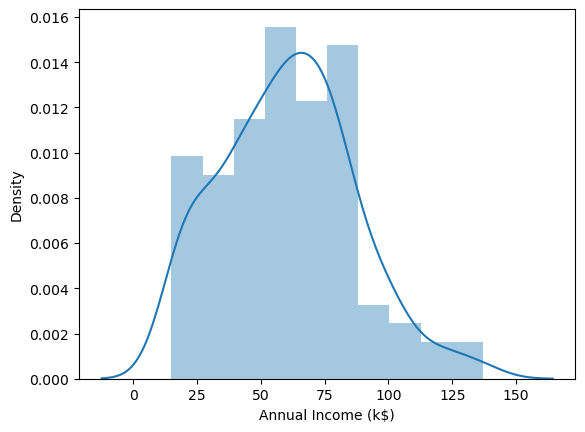

In [18]:
#creating histogram
sns.distplot(df['Annual Income (k$)'])

In [19]:
# we can see this is an example of a normal distribution

In [20]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

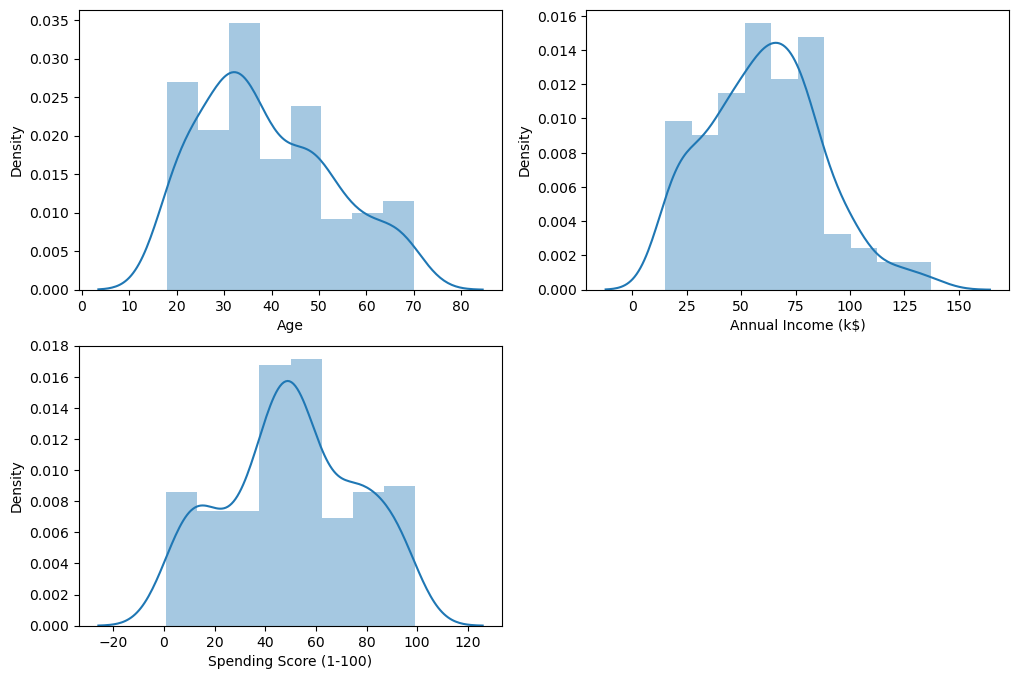

In [40]:
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# for i in cols:
#     plt.figure() # this will create a new figure each time it runs 
#     sns.distplot(df[i])

# better

plt.figure(figsize=(12,8))
for i,col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.distplot(df[col])


<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

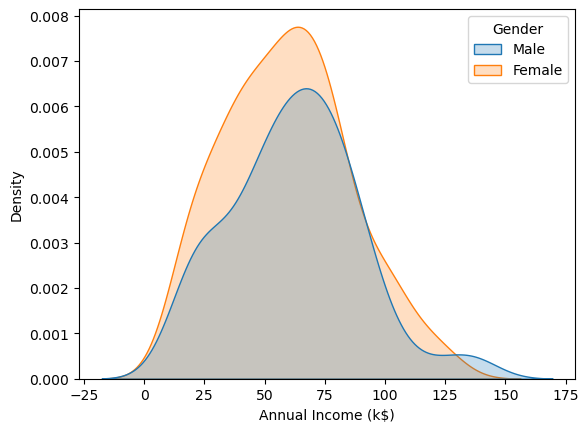

In [36]:
# we can also use kde plot
# we will break down annual income based on gender 
sns.kdeplot(data = df, x = 'Annual Income (k$)', hue = 'Gender' , fill = True)

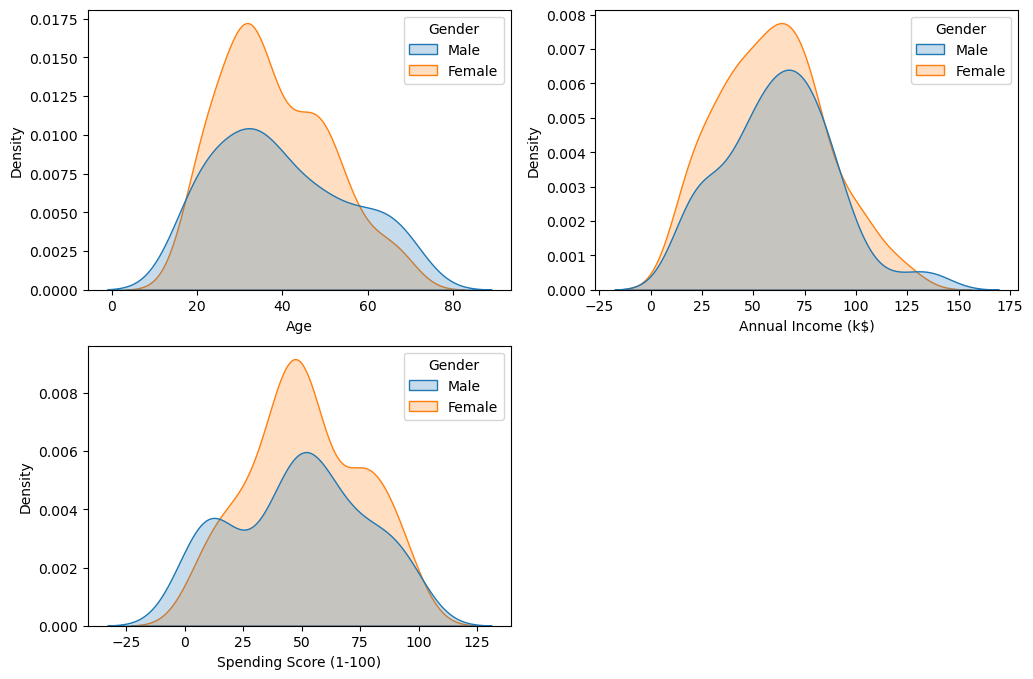

In [41]:
plt.figure(figsize=(12,8))

for i,col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.kdeplot(data = df, x = col, hue = 'Gender' , fill = True)

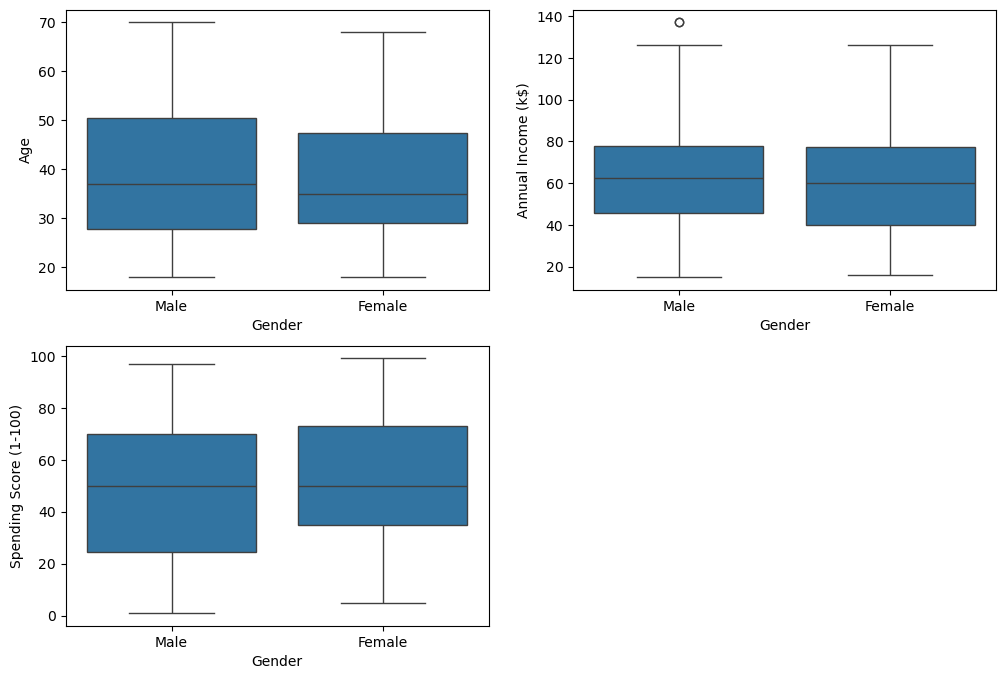

In [46]:
# now we will also use a box plot

plt.figure(figsize = (12,8))
for i,col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(data = df, x = 'Gender', y = col)  

In [48]:
df['Gender'].value_counts(normalize = True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

In [49]:
# BIVARIATE ANALYSIS

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

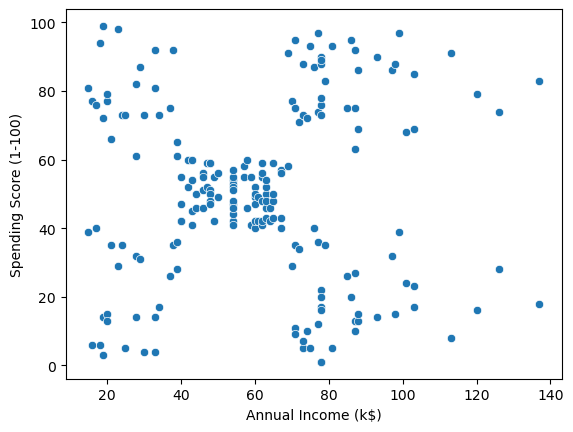

In [50]:
# we will use scatter plot

sns.scatterplot(data = df, x = 'Annual Income (k$)' , y = 'Spending Score (1-100)')

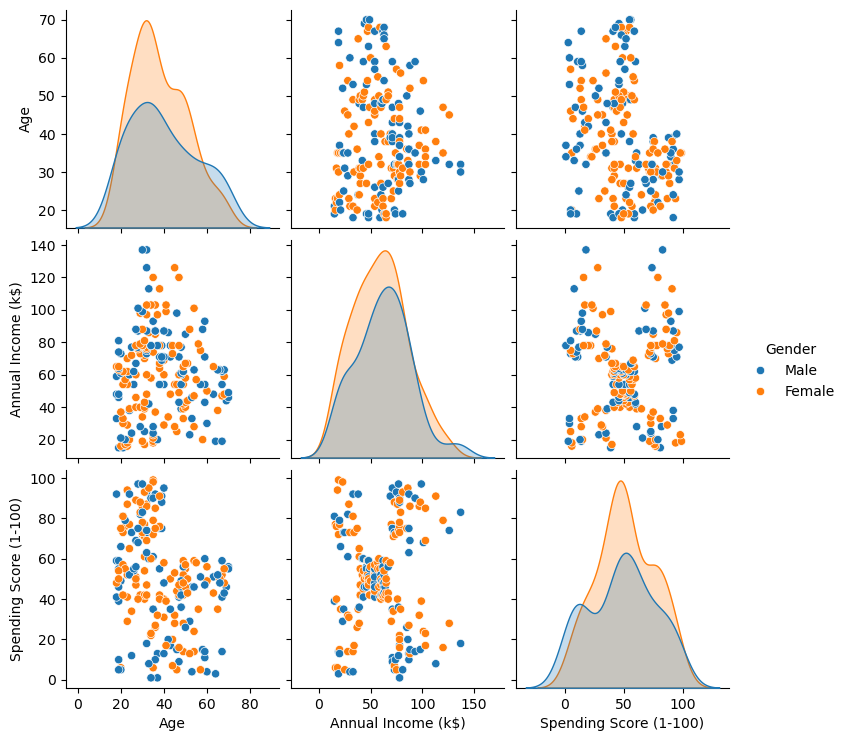

In [53]:
# we dont actually need customerid, so dropping it

df2 = df.drop('CustomerID', axis = 1)
sns.pairplot(df2, hue = 'Gender')

In [61]:
df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [67]:
# now we will look at corr. we dont want customerID, so we wil use df2
df2.corr(numeric_only = True)

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

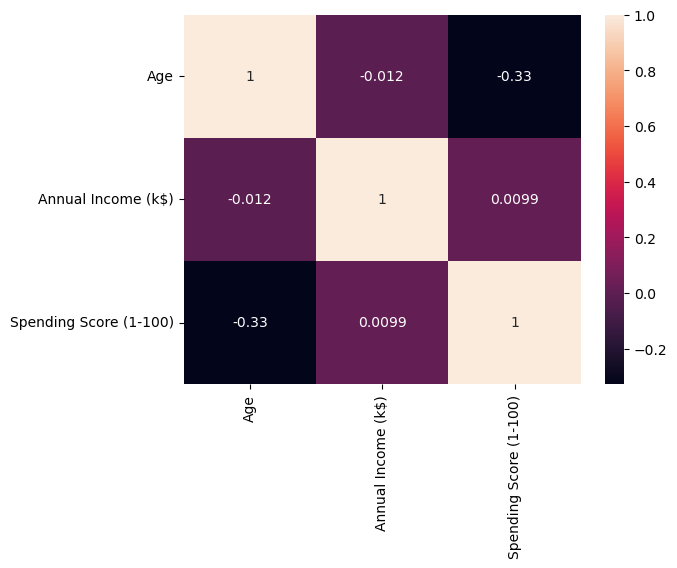

In [68]:
# creating a heatmap

sns.heatmap(df2.corr(numeric_only = True), annot = True)

In [ ]:
# Now we have done EDA
# Now we will initate clustering

In [69]:
# Clutering - Univariate, Bivariate, Multivariate

In [90]:
# Initiating the algo

clustering1 = KMeans(n_clusters = 3)

In [92]:
clustering1.fit(df2[['Annual Income (k$)']])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [104]:
clustering1.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [105]:
df2['income_cluster'] =  clustering1.labels_
df2.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),income_cluster
0,Male,19,15,39,0
1,Male,21,15,81,0
2,Female,20,16,6,0
3,Female,23,16,77,0
4,Female,31,17,40,0
5,Female,22,17,76,0
6,Female,35,18,6,0
7,Female,23,18,94,0
8,Male,64,19,3,0
9,Female,30,19,72,0


In [106]:
df['income_cluster'].value_counts()

income_cluster
2    92
0    72
1    36
Name: count, dtype: int64

In [107]:
# to optimize number of clusters , we will use intertia method
# this gives us a val, and that val is the distance b/w centroids, so we need to make it relatively low
clustering1.inertia_

23528.152173913044

In [108]:
inertia_scores = []

for i in range(1,12):
    clust = KMeans(n_clusters = i)
    clust.fit(df2[['Annual Income (k$)']])  
    inertia_scores.append(clust.inertia_)

inertia_scores

[137277.28000000003,
 48660.88888888889,
 25640.457784396836,
 14647.235170393065,
 8481.49619047619,
 5496.5339376218335,
 3993.628787878788,
 3351.771199388846,
 2412.1663614163613,
 2108.206277056277,
 1335.5418414918415]

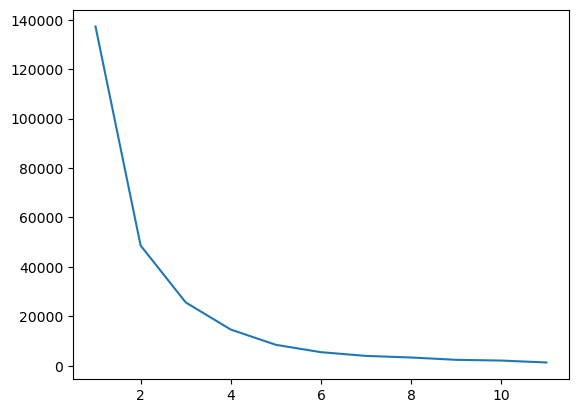

In [109]:
plt.plot(range(1,12), inertia_scores)

In [110]:
# we can look that elbow starts at 3. so  using that in the above code.

In [111]:
df2.groupby('income_cluster')[['Age', 'Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
income_cluster,,,
0,38.930556,33.027778,50.166667
1,37.833333,99.888889,50.638889
2,39.184783,66.717391,50.054348


In [ ]:
#bivariate clustering

In [119]:
clustering2 = KMeans(n_clusters = 5)
clustering2.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
 
clustering2.labels_ 

df2['spending_and_income_cluster'] = clustering2.labels_

In [120]:
df2.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),income_cluster,spending_and_income_cluster
0,Male,19,15,39,0,4
1,Male,21,15,81,0,2
2,Female,20,16,6,0,4
3,Female,23,16,77,0,2
4,Female,31,17,40,0,4


In [117]:
inertia_scores2 = []

for i in range(1,12):
    clust = KMeans(n_clusters = i)
    clust.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
    inertia_scores2.append(clust.inertia_)

inertia_scores2

[269981.27999999997,
 183714.08082173267,
 106348.37306211119,
 73679.78903948836,
 44454.47647967974,
 38463.49408903117,
 31898.925198412697,
 31304.02703962704,
 21932.39204424098,
 21333.789672550945,
 20497.831339217613]

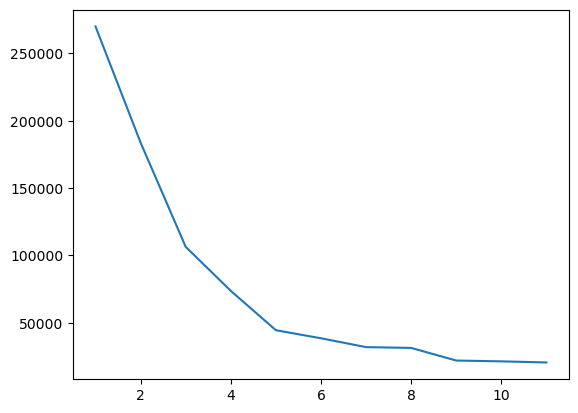

In [118]:
plt.plot(range(1,12),inertia_scores2)

In [ ]:
# we can observe elbow is at 5. so we are using n_clusters = 5

In [133]:
# we want to show the centres of each cluster also 

centres = pd.DataFrame(clustering2.cluster_centers_)
centres.columns = ['x','y']
centres

,x,y
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


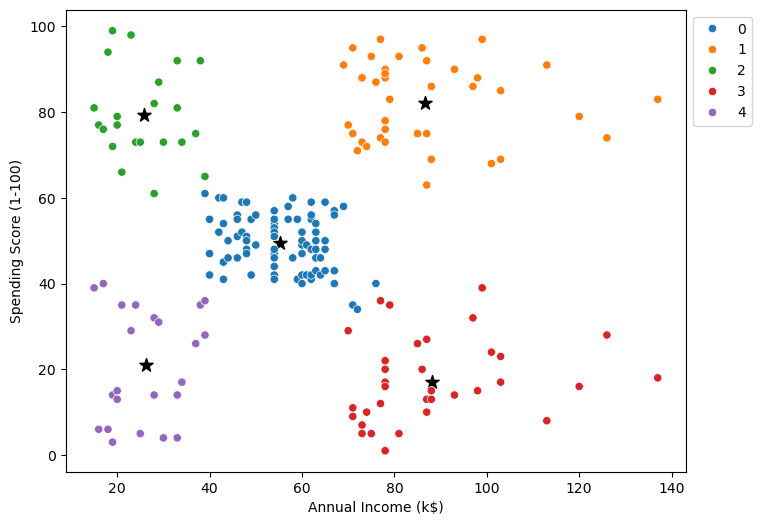

In [174]:
# lets visualize it by scatter plot
plt.figure(figsize = (8,6))
plt.scatter(x = centres['x'], y = centres['y'], s = 100, c = 'black', marker = '*') 

sns.scatterplot(data = df2, x = 'Annual Income (k$)', y = 'Spending Score (1-100)', hue = 'spending_and_income_cluster', palette = 'tab10')
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig('Cluster.png')

In [151]:
pd.crosstab(df2['spending_and_income_cluster'], df2['Gender'], normalize = 'index')

Gender,Female,Male
spending_and_income_cluster,,
0,0.592593,0.407407
1,0.538462,0.461538
2,0.590909,0.409091
3,0.457143,0.542857
4,0.608696,0.391304


In [153]:
df2.groupby('spending_and_income_cluster')[['Age', 'Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
spending_and_income_cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [154]:
# multivariate cluster

from sklearn.preprocessing import StandardScaler # this will allow to scale the data on the same scale

In [155]:
scale = StandardScaler()

In [156]:
df2.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),income_cluster,spending_and_income_cluster
0,Male,19,15,39,0,4
1,Male,21,15,81,0,2
2,Female,20,16,6,0,4
3,Female,23,16,77,0,2
4,Female,31,17,40,0,4


In [158]:
# gender must be turned into numbers

df3 = pd.get_dummies(df2, drop_first = True)
df3.head()

,Age,Annual Income (k$),Spending Score (1-100),income_cluster,spending_and_income_cluster,Gender_Male
0,19,15,39,0,4,True
1,21,15,81,0,2,True
2,20,16,6,0,4,False
3,23,16,77,0,2,False
4,31,17,40,0,4,False


In [159]:
df3.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'income_cluster',
       'spending_and_income_cluster', 'Gender_Male'],
      dtype='object')

In [160]:
df3 = df3[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']]

In [161]:
df3.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [162]:
df3 = scale.fit_transform(df3)

In [164]:
df3 = pd.DataFrame(scale.fit_transform(df3))

In [165]:
df3.head()

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


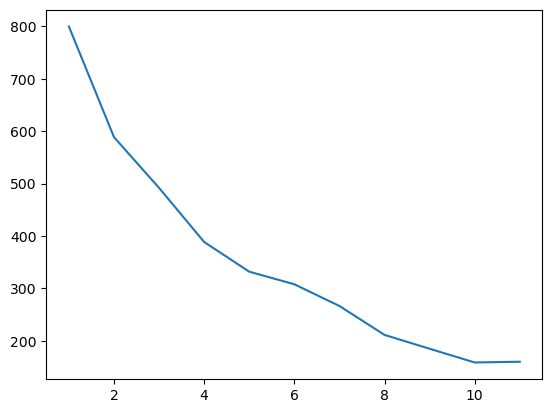

In [167]:
inertia_scores3 = []

for i in range(1,12):
    clust = KMeans(n_clusters = i)
    clust.fit(df3)
    inertia_scores3.append(clust.inertia_)

plt.plot(range(1,12),inertia_scores3)

In [ ]:
# elbow is at 4

In [168]:
#we can do the same for this also, but there is no real need

In [169]:
df2.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),income_cluster,spending_and_income_cluster
0,Male,19,15,39,0,4
1,Male,21,15,81,0,2
2,Female,20,16,6,0,4
3,Female,23,16,77,0,2
4,Female,31,17,40,0,4


In [170]:
#saving df2 as csv 

In [173]:
df2.to_csv('Clustering.csv') 